<a href="https://colab.research.google.com/github/Alaebal/indexation-projects/blob/main/tp3_alaebalbali_2cs1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
files = ['/img1.jpg', '/img2.jpg', '/img3.jpg', '/img4.jpg', '/img5.jpg']
print("Fichiers trouvés :", files)

Fichiers trouvés : ['/img1.jpg', '/img2.jpg', '/img3.jpg', '/img4.jpg', '/img5.jpg']


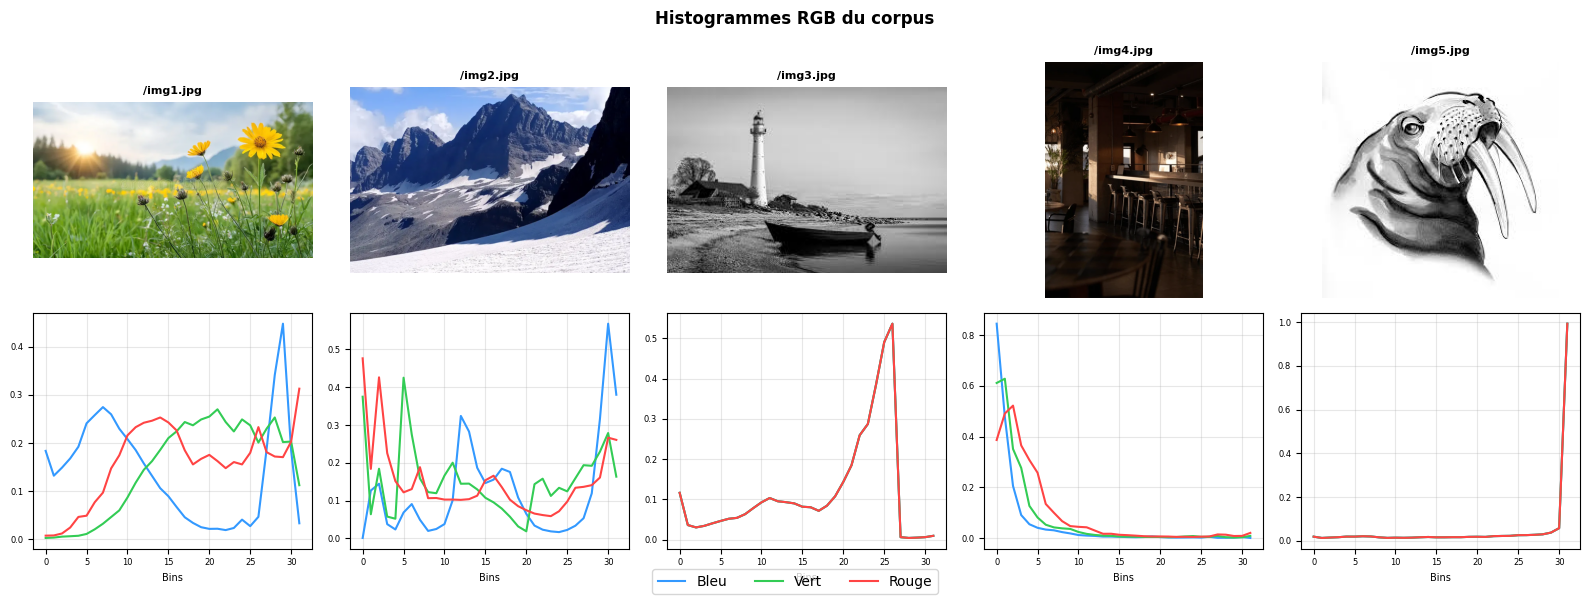

5 images indexées
Dimension du descripteur : 512 (= 8 x 8 x 8 bins)


In [ ]:

def extract_histogram(image_path, bins=8):
    img = cv2.imread(image_path)
    if img is None:
        return None

    img = cv2.resize(img, (256, 256))

    # Histogramme 3D BGR
    hist = cv2.calcHist([img], [0, 1, 2], None,
                        [bins, bins, bins], [0, 256] * 3)

    # Normalisation
    hist = cv2.normalize(hist, hist).flatten()

    return hist


# ─────────────────────────────────────────────
# Visualisation images + histogrammes
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, len(files), figsize=(16, 6))

chan_colors = ['#3399FF', '#33CC55', '#FF4444']
chan_names = ['Bleu', 'Vert', 'Rouge']

for i, f in enumerate(files):
    path = os.path.join(image_folder, f)
    img = cv2.imread(path)

    if img is None:
        continue

    # Ligne 1 : image
    axes[0][i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0][i].set_title(f, fontsize=8, fontweight='bold')
    axes[0][i].axis('off')

    # Ligne 2 : histogrammes RGB
    for c, (col, name) in enumerate(zip(chan_colors, chan_names)):
        h = cv2.calcHist([img], [c], None, [32], [0, 256])
        h = cv2.normalize(h, h).flatten()

        axes[1][i].plot(h, color=col, linewidth=1.5,
                        label=name if i == 0 else "")

    axes[1][i].set_xlabel('Bins', fontsize=7)
    axes[1][i].tick_params(labelsize=6)
    axes[1][i].grid(alpha=0.3)

fig.legend(['Bleu', 'Vert', 'Rouge'], loc='lower center', ncol=3)
plt.suptitle('Histogrammes RGB du corpus', fontweight='bold')
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
#  Construction de l'index
# ─────────────────────────────────────────────
index_hist = {}

for f in files:
    path = os.path.join(image_folder, f)
    h = extract_histogram(path)

    if h is not None:
        index_hist[f] = h

print(f"{len(index_hist)} images indexées")

# dimension du descripteur
if len(index_hist) > 0:
    first_hist = list(index_hist.values())[0]
    print(f"Dimension du descripteur : {len(first_hist)} (= 8 x 8 x 8 bins)")







1.
Les deux images sont en niveaux de gris → même distribution d'intensités, même si les sujets sont totalement différents.
2.
Le descripteur devient plus précis mais aussi plus grand et plus sensible au bruit. Deux images légèrement différentes auront des histogrammes plus éloignés.
3.
Il compte les pixels indépendamment de leur position. Une prairie et la même image retournée donnent le même histogramme.

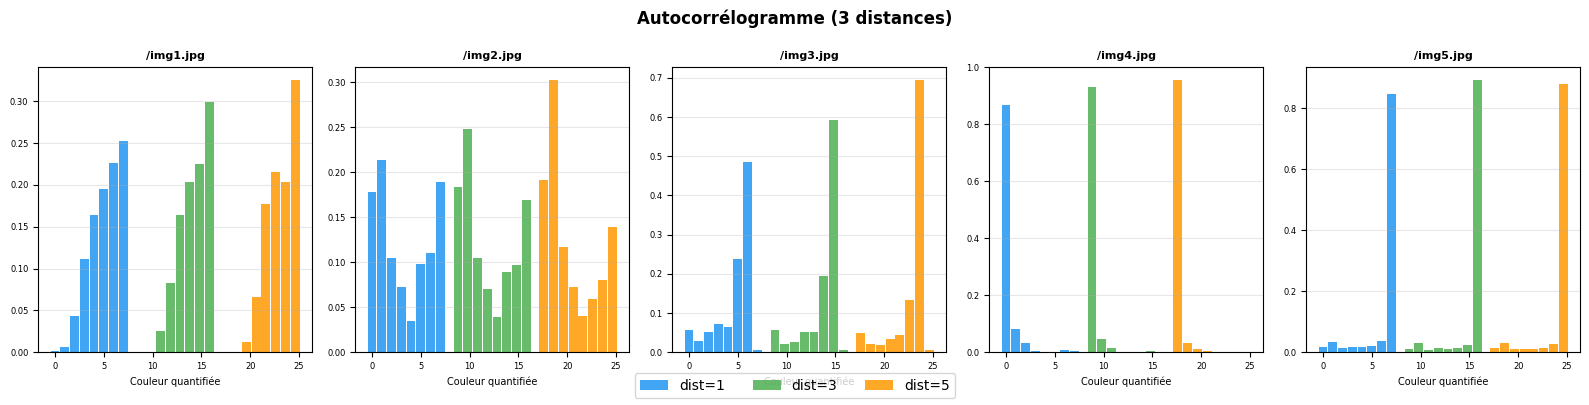

5 images indexées


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ─────────────────────────────────────────────
# 🔹 Quantification
# ─────────────────────────────────────────────
def quantize_image(img, bins=8):
    """Réduit l'image à 'bins' niveaux de couleur par canal."""
    factor = 256 // bins
    return (img // factor).astype(np.uint8)


# ─────────────────────────────────────────────
# 🔹 Autocorrélogramme
# ─────────────────────────────────────────────
def autocorrelogram(image_path, bins=8, distances=[1, 3, 5]):
    img = cv2.imread(image_path)
    if img is None:
        return None

    img = cv2.resize(img, (64, 64))
    img_q = quantize_image(img, bins)

    h, w, _ = img_q.shape
    descriptor = []

    for dist in distances:
        corr = np.zeros(bins, dtype=np.float32)

        for y in range(dist, h - dist):
            for x in range(dist, w - dist):
                c = int(img_q[y, x, 1])  # canal vert

                voisins = [
                    img_q[y - dist, x, 1],
                    img_q[y + dist, x, 1],
                    img_q[y, x - dist, 1],
                    img_q[y, x + dist, 1],
                ]

                for v in voisins:
                    if int(v) == c:
                        corr[c] += 1

        total = corr.sum()
        if total > 0:
            corr /= total

        descriptor.extend(corr)

    return np.array(descriptor, dtype=np.float32)


# ─────────────────────────────────────────────
# 🔹 Visualisation
# ─────────────────────────────────────────────
dist_labels = ['dist=1', 'dist=3', 'dist=5']
dist_colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(1, len(files), figsize=(16, 4))

for i, f in enumerate(files):
    path = os.path.join(image_folder, f)
    desc = autocorrelogram(path)

    if desc is None:
        continue

    for j in range(3):
        chunk = desc[j * 8: (j + 1) * 8]
        x_off = np.arange(8) + j * 8 * 1.1

        axes[i].bar(
            x_off,
            chunk,
            color=dist_colors[j],
            label=dist_labels[j] if i == 0 else '',
            alpha=0.85,
            width=0.9
        )

    axes[i].set_title(f, fontsize=8, fontweight='bold')
    axes[i].set_xlabel('Couleur quantifiée', fontsize=7)
    axes[i].tick_params(labelsize=6)
    axes[i].grid(axis='y', alpha=0.3)

fig.legend(dist_labels, loc='lower center', ncol=3)
plt.suptitle('Autocorrélogramme (3 distances)', fontweight='bold')
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 🔹 Construction de l'index
# ─────────────────────────────────────────────
index_corr = {}

for f in files:
    path = os.path.join(image_folder, f)
    d = autocorrelogram(path)

    if d is not None:
        index_corr[f] = d

print(f"{len(index_corr)} images indexées")

Pourquoi le corrélogramme différencie-t-il mieux img3 et img5 ?
Il tient compte de la disposition spatiale des pixels. Même si les deux images ont les mêmes tons de gris, leur structure spatiale (phare = zones lisses, morses = textures irrégulières) diffère → descripteurs différents.
Valeur élevée à k=1 vs k=5 ?
k=1 élevé → pixels voisins immédiats souvent de même couleur = texture fine et uniforme. k=5 élevé → la régularité se maintient sur une plus grande distance = texture large et homogène.

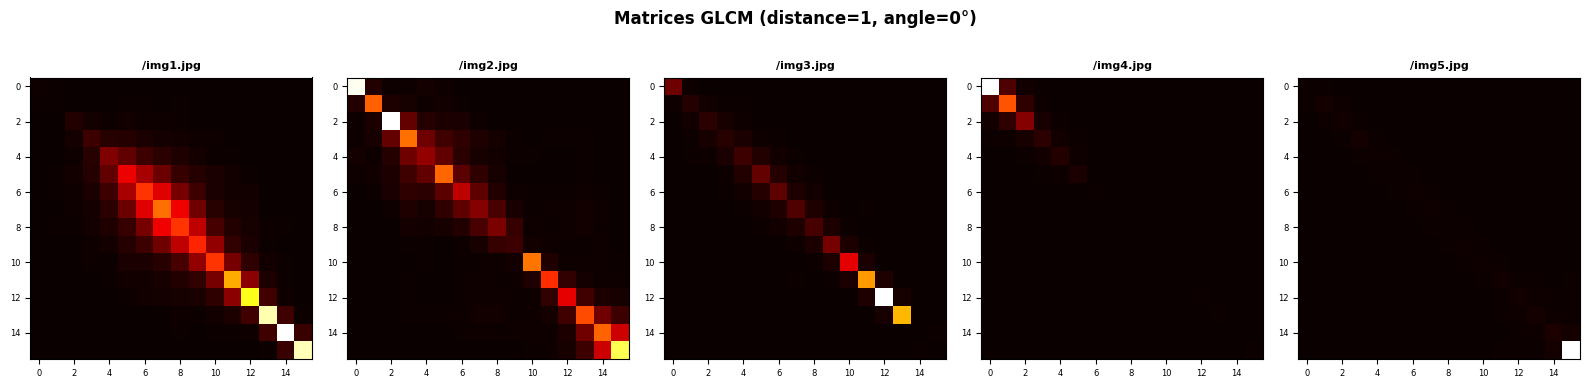

5 images indexées
Dimension : 24


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage.feature import graycomatrix, graycoprops

# ─────────────────────────────────────────────
# 🔹 Extraction GLCM
# ─────────────────────────────────────────────
def extract_glcm(image_path, distances=[1, 3],
                 angles=[0, np.pi/4, np.pi/2]):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    img = cv2.resize(img, (128, 128))

    # Quantification : 16 niveaux de gris
    img = (img // 16).astype(np.uint8)

    glcm = graycomatrix(
        img,
        distances=distances,
        angles=angles,
        levels=16,
        symmetric=True,
        normed=True
    )

    features = []

    for prop in ['contrast', 'homogeneity', 'energy', 'correlation']:
        values = graycoprops(glcm, prop)
        features.extend(values.flatten())

    return np.array(features, dtype=np.float32)


# ─────────────────────────────────────────────
# 🔹 Visualisation GLCM
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, len(files), figsize=(16, 4))

for i, f in enumerate(files):
    path = os.path.join(image_folder, f)

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    img = cv2.resize(img, (128, 128))
    img = (img // 16).astype(np.uint8)

    glcm = graycomatrix(
        img,
        [1],
        [0],
        levels=16,
        symmetric=True,
        normed=True
    )

    axes[i].imshow(
        glcm[:, :, 0, 0],
        cmap='hot',
        interpolation='nearest'
    )

    axes[i].set_title(f, fontsize=8, fontweight='bold')
    axes[i].tick_params(labelsize=6)

plt.suptitle('Matrices GLCM (distance=1, angle=0°)', fontweight='bold')
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 🔹 Construction de l'index
# ─────────────────────────────────────────────
index_glcm = {}

for f in files:
    path = os.path.join(image_folder, f)
    d = extract_glcm(path)

    if d is not None:
        index_glcm[f] = d

print(f"{len(index_glcm)} images indexées")

if len(index_glcm) > 0:
    dim = len(next(iter(index_glcm.values())))
    print(f"Dimension : {dim}")


Quelle image a la texture la plus uniforme ?
img2 (neige) : sa GLCM est très concentrée sur la diagonale, ce qui signifie que les pixels voisins ont presque toujours la même intensité → surface lisse et homogène.
Différence fondamentale couleur vs texture ?
Le descripteur de couleur répond à quelles couleurs sont présentes, tandis que le descripteur de texture répond à comment les pixels sont organisés spatialement, indépendamment de la couleur.

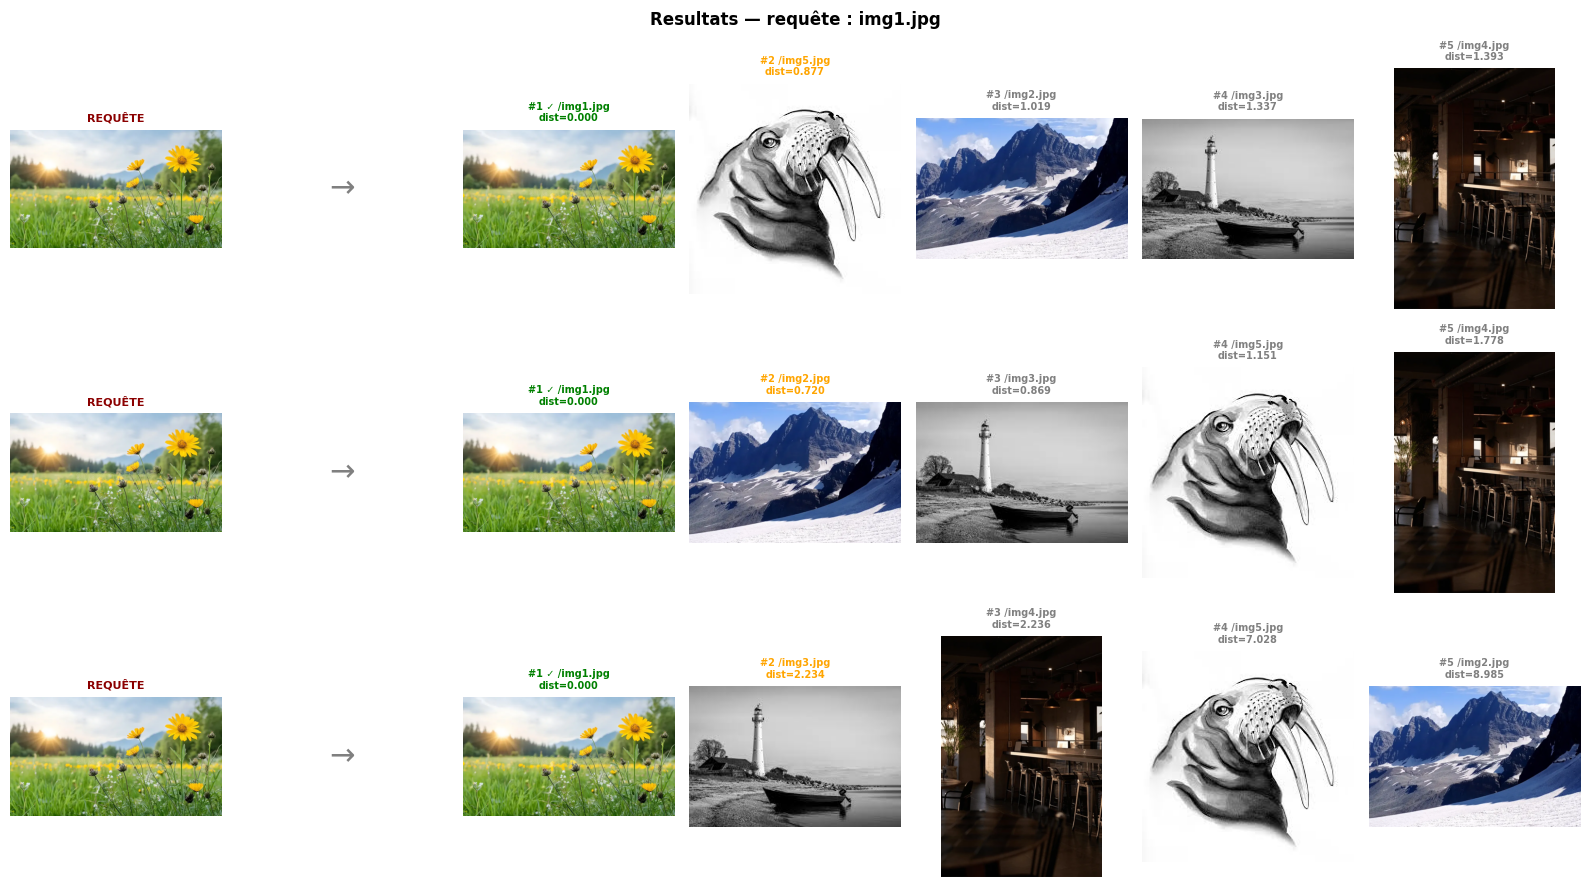

In [ ]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 🔹 Recherche
# ─────────────────────────────────────────────
def search(query_path, index, extract_fn, top_k=5):
    """Recherche les images les plus similaires (distance L2)."""

    q = extract_fn(query_path)
    if q is None:
        return []

    dists = {
        name: np.linalg.norm(q - desc)
        for name, desc in index.items()
    }

    return sorted(dists.items(), key=lambda x: x[1])[:top_k]


# ─────────────────────────────────────────────
# 🔹 Affichage des résultats
# ─────────────────────────────────────────────
def afficher_resultats(query_path, results_dict, image_folder):

    methods = list(results_dict.keys())
    n_res = max(len(r) for r in results_dict.values())

    fig, axes = plt.subplots(
        len(methods),
        n_res + 2,
        figsize=(16, 3 * len(methods))
    )

    method_colors = {
        'Histogramme': '#1565C0',
        'Corrélogramme': '#2E7D32',
        'GLCM': '#E65100'
    }

    for mi, method in enumerate(methods):
        results = results_dict[method]

        # Image requête
        q_img = cv2.cvtColor(
            cv2.imread(query_path),
            cv2.COLOR_BGR2RGB
        )

        axes[mi][0].imshow(q_img)
        axes[mi][0].set_title(
            'REQUÊTE',
            fontsize=8,
            fontweight='bold',
            color='darkred'
        )
        axes[mi][0].axis('off')

        axes[mi][0].set_ylabel(
            method,
            fontsize=9,
            color=method_colors[method],
            fontweight='bold',
            rotation=90
        )

        # Flèche
        axes[mi][1].axis('off')
        axes[mi][1].text(
            0.5, 0.5, '→',
            fontsize=22,
            ha='center',
            va='center',
            color='gray'
        )

        # Résultats
        for ri, (name, dist) in enumerate(results[:n_res]):

            img = cv2.cvtColor(
                cv2.imread(os.path.join(image_folder, name)),
                cv2.COLOR_BGR2RGB
            )

            axes[mi][ri + 2].imshow(img)

            rank = '#1 ✓' if ri == 0 else f'#{ri + 1}'
            col = 'green' if ri == 0 else 'orange' if ri == 1 else 'gray'

            axes[mi][ri + 2].set_title(
                f'{rank} {name}\ndist={dist:.3f}',
                fontsize=7,
                color=col,
                fontweight='bold'
            )

            axes[mi][ri + 2].axis('off')

    plt.suptitle(
        f'Resultats — requête : {os.path.basename(query_path)}',
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────
# 🔹 Lancement
# ─────────────────────────────────────────────
query = os.path.join(image_folder, files[0])

results_dict = {
    'Histogramme': search(query, index_hist, extract_histogram),
    'Corrélogramme': search(query, index_corr, autocorrelogram),
    'GLCM': search(query, index_glcm, extract_glcm),
}

afficher_resultats(query, results_dict, image_folder)

Les trois méthodes placent toujours img1 en #1 (distance 0), mais divergent ensuite. L'histogramme confond img4 avec img1 car leurs tons globaux se ressemblent. Le corrélogramme remonte img3 grâce à la structure spatiale. La GLCM isole nettement img4 (distance 9.01) car sa texture est très distinctive. Conclusion : les méthodes sont complémentaires, aucune n'est parfaite seule.
Questions Bilan
1. Pourquoi la recherche d'images est plus complexe ?
Une image ne contient pas de mots indexables, seulement des pixels. Il faut la convertir en descripteur numérique, qui ne capture qu'un aspect visuel partiel — jamais le sens complet (fossé sémantique).
2. Pourquoi img3 et img5 ont des histogrammes similaires ?
Les deux sont en niveaux de gris avec une distribution d'intensités comparable. L'histogramme ne voit que quelles intensités sont présentes, pas comment elles sont arrangées.
3. Quand préférer la GLCM à l'histogramme ?
Quand la couleur est absente ou non discriminante et que c'est la texture qui compte : imagerie médicale (IRM, radio), contrôle qualité industriel, analyse de matériaux.